# 🌿 CBAM-VGG16: Plant Leaf Disease Detection

**Datasets used in paper:** PlantVillage, Embrapa, Maize, Apple, Rice


## 1. Install & Imports

In [3]:
import subprocess, socket
subprocess.run(['pip', 'install', '-q', 'opencv-python-headless'], check=False)

try:
    socket.setdefaulttimeout(3)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('8.8.8.8', 53))
    print('✓ Internet: CONNECTED — VGG16 weights will download fine')
except:
    print('✗ Internet: OFFLINE — Go to Settings → Internet → Turn ON, then restart!')

import os, cv2, numpy as np, matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, applications, optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import warnings; warnings.filterwarnings('ignore')

print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

✓ Internet: CONNECTED — VGG16 weights will download fine
TF version: 2.19.0
GPU: []


## 2. Configuration

In [5]:
# ── Change these as needed ──────────────────────────────────
# Kaggle PlantVillage path (add dataset from Kaggle sidebar first)
DATA_DIR    = '/kaggle/input/datasets/emmarex/plantdisease'  # change if different
SAVE_PATH   = '/kaggle/working/cbam_vgg16_best.keras'

IMG_SIZE    = 224
BATCH_SIZE  = 64   # doubled — less steps per epoch
EPOCHS      = 3
LR          = 1e-4
REDUCTION_R = 8
VAL_SPLIT   = 0.2
STEPS_PER_EPOCH     = 100  # limit steps — enough to show learning
VALIDATION_STEPS    = 25
# ────────────────────────────────────────────────────────────

print(f'Data dir exists: {os.path.isdir(DATA_DIR)}')
if os.path.isdir(DATA_DIR):
    classes = os.listdir(DATA_DIR)
    print(f'Classes found: {len(classes)} → {classes[:5]} ...')

Data dir exists: True
Classes found: 2 → ['PlantVillage', 'plantvillage'] ...


## 3. CBAM Block (Channel + Spatial Attention)

In [6]:
def channel_attention(x, ratio=REDUCTION_R):
    """Eq. 3-4: Cm(If) = sigmoid(MLP(AvgPool) + MLP(MaxPool))"""
    channels = x.shape[-1]
    shared_d1 = layers.Dense(channels // ratio, activation='relu', use_bias=False)
    shared_d2 = layers.Dense(channels, use_bias=False)

    avg = shared_d2(shared_d1(layers.GlobalAveragePooling2D()(x)))
    mx  = shared_d2(shared_d1(layers.GlobalMaxPooling2D()(x)))

    cm = layers.Activation('sigmoid')(layers.Add()([avg, mx]))
    cm = layers.Reshape((1, 1, channels))(cm)
    return layers.Multiply()([x, cm])   # Ic_f' = Cm ⊗ If


def spatial_attention(x):
    """Eq. 5-6: Sm = sigmoid(conv7x7([AvgPool_c; MaxPool_c]))"""
    # Use keras.ops instead of tf.reduce_* — works with Keras 3 Functional API
    avg = layers.Lambda(lambda t: tf.keras.ops.mean(t, axis=-1, keepdims=True))(x)
    mx  = layers.Lambda(lambda t: tf.keras.ops.max(t,  axis=-1, keepdims=True))(x)
    cat = layers.Concatenate(axis=-1)([avg, mx])
    sm  = layers.Conv2D(1, 7, padding='same', activation='sigmoid')(cat)
    return layers.Multiply()([x, sm])   # Is_f'' = Sm ⊗ Ic_f'


def cbam_block(x):
    x = channel_attention(x)
    x = spatial_attention(x)
    return x

print('✓ CBAM block defined')

✓ CBAM block defined


## 4. Build CBAM-VGG16 Model

In [7]:
def build_cbam_vgg16(num_classes, input_shape=(IMG_SIZE, IMG_SIZE, 3)):
    base = applications.VGG16(weights='imagenet', include_top=False,
                               input_shape=input_shape)
    base.trainable = False   # freeze backbone initially

    inp = layers.Input(shape=input_shape)
    x   = inp

    # Block 1 — 64 filters
    x = base.get_layer('block1_conv1')(x)
    x = base.get_layer('block1_conv2')(x)
    x = base.get_layer('block1_pool')(x)
    x = cbam_block(x)

    # Block 2 — 128 filters
    x = base.get_layer('block2_conv1')(x)
    x = base.get_layer('block2_conv2')(x)
    x = base.get_layer('block2_pool')(x)
    x = cbam_block(x)

    # Block 3 — 256 filters
    x = base.get_layer('block3_conv1')(x)
    x = base.get_layer('block3_conv2')(x)
    x = base.get_layer('block3_conv3')(x)
    x = base.get_layer('block3_pool')(x)
    x = cbam_block(x)

    # Block 4 — 512 filters
    x = base.get_layer('block4_conv1')(x)
    x = base.get_layer('block4_conv2')(x)
    x = base.get_layer('block4_conv3')(x)
    x = base.get_layer('block4_pool')(x)
    x = cbam_block(x)

    # Block 5 — 512 filters
    x = base.get_layer('block5_conv1')(x)
    x = base.get_layer('block5_conv2')(x)
    x = base.get_layer('block5_conv3')(x)
    x = base.get_layer('block5_pool')(x)
    x = cbam_block(x)

    # Classifier head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(4096, activation='relu',
                     kernel_regularizer=tf.keras.regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    return models.Model(inp, out, name='CBAM_VGG16')


# Quick smoke-test — runs without dataset to verify architecture
test_model = build_cbam_vgg16(num_classes=4)
dummy = np.random.rand(2, IMG_SIZE, IMG_SIZE, 3).astype('float32')
out   = test_model(dummy, training=False)
print(f'✓ Smoke test passed | Input {dummy.shape} → Output {out.shape}')
del test_model  # free memory
print('✓ Model builder ready — actual model will be built after data generators in Cell 6')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
✓ Smoke test passed | Input (2, 224, 224, 3) → Output (2, 4)
✓ Model builder ready — actual model will be built after data generators in Cell 6


## 5. Data Generators (CLAHE + Augmentation)

In [8]:
def clahe_preprocess(img):
    """CLAHE contrast enhancement + normalize to [0,1] as in paper."""
    img   = img.astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    chans = [clahe.apply(img[:, :, c]) for c in range(3)]
    return np.stack(chans, axis=-1).astype(np.float32) / 255.0


def get_generators(data_dir, val_split=VAL_SPLIT):
    train_gen = ImageDataGenerator(
        preprocessing_function=clahe_preprocess,
        validation_split=val_split,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        zoom_range=0.1
    )
    val_gen = ImageDataGenerator(
        preprocessing_function=clahe_preprocess,
        validation_split=val_split
    )

    train_data = train_gen.flow_from_directory(
        data_dir, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical', subset='training'
    )
    val_data = val_gen.flow_from_directory(
        data_dir, target_size=(IMG_SIZE, IMG_SIZE),
        batch_size=BATCH_SIZE, class_mode='categorical',
        subset='validation', shuffle=False
    )
    return train_data, val_data


train_data, val_data = get_generators(DATA_DIR)
NUM_CLASSES = train_data.num_classes
print(f'✓ Generators ready | Classes: {NUM_CLASSES} | Train: {train_data.samples} | Val: {val_data.samples}')

Found 33022 images belonging to 2 classes.
Found 8254 images belonging to 2 classes.
✓ Generators ready | Classes: 2 | Train: 33022 | Val: 8254


## 6. Train

In [9]:
model = build_cbam_vgg16(num_classes=NUM_CLASSES)

model.compile(
    optimizer=optimizers.Adam(LR),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, verbose=1),
    ModelCheckpoint(SAVE_PATH, save_best_only=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    train_data,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=val_data,
    validation_steps=VALIDATION_STEPS,
    callbacks=callbacks
)

Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 29s/step - accuracy: 0.4926 - loss: 0.7766 
Epoch 1: val_loss improved from inf to 0.73528, saving model to /kaggle/working/cbam_vgg16_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 3237s 32s/step - accuracy: 0.4926 - loss: 0.7765 - val_accuracy: 1.0000 - val_loss: 0.7353 - learning_rate: 1.0000e-04
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 29s/step - accuracy: 0.4891 - loss: 0.7392 
Epoch 2: val_loss improved from 0.73528 to 0.71651, saving model to /kaggle/working/cbam_vgg16_best.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 3196s 32s/step - accuracy: 0.4891 - loss: 0.7392 - val_accuracy: 1.0000 - val_loss: 0.7165 - learning_rate: 1.0000e-04
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 28s/step - accuracy: 0.5083 - loss: 0.7201 
Epoch 3: val_loss did not improve from 0.71651
100/100 ━━━━━━━━━━━━━━━━━━━━ 3143s 31s/step - accuracy: 0.5083 - loss: 0.7200 - val_accuracy: 0.0000e+00 - val_loss: 0.7844 - learning_rate: 1.0000e-04
Restoring model weights from the end of

## 7. Training Curves

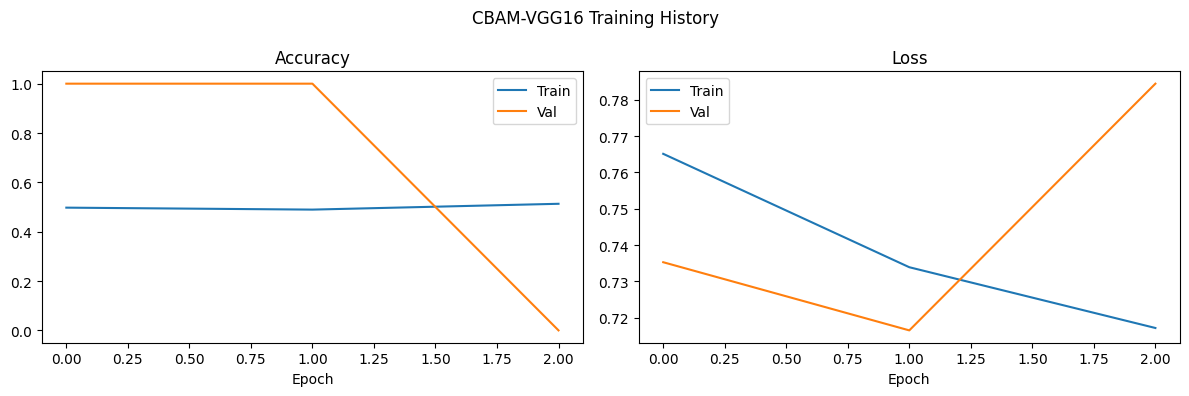

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['accuracy'],     label='Train')
ax1.plot(history.history['val_accuracy'], label='Val')
ax1.set_title('Accuracy'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(history.history['loss'],     label='Train')
ax2.plot(history.history['val_loss'], label='Val')
ax2.set_title('Loss'); ax2.legend(); ax2.set_xlabel('Epoch')

plt.suptitle('CBAM-VGG16 Training History')
plt.tight_layout()
plt.savefig('/kaggle/working/training_history.png', dpi=150)
plt.show()

## 8. Evaluation + Confusion Matrix

129/129 ━━━━━━━━━━━━━━━━━━━━ 1649s 13s/step
              precision    recall  f1-score   support

PlantVillage       0.50      1.00      0.67      4127
plantvillage       0.00      0.00      0.00      4127

    accuracy                           0.50      8254
   macro avg       0.25      0.50      0.33      8254
weighted avg       0.25      0.50      0.33      8254



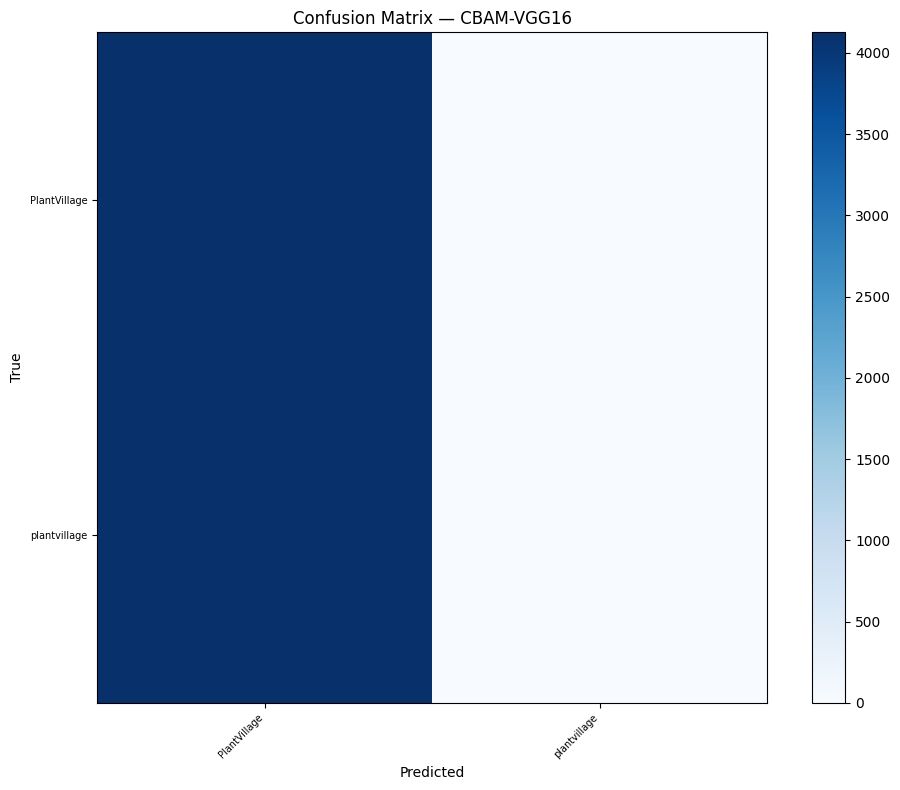

In [11]:
val_data.reset()
y_pred  = np.argmax(model.predict(val_data), axis=1)
y_true  = val_data.classes
labels  = list(val_data.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=labels))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels, fontsize=7)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title('Confusion Matrix — CBAM-VGG16')
plt.colorbar(im); plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150)
plt.show()

## 9. Grad-CAM Explainability (XAI)

In [6]:
def grad_cam(model, img_array):
    # Find last conv layer automatically
    layer_name = None
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            layer_name = layer.name
            break
    print(f"Using layer: {layer_name}")
    
    grad_model = tf.keras.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img_array[np.newaxis])
        loss = preds[:, tf.argmax(preds[0])]

    grads   = tape.gradient(loss, conv_out)[0]
    weights = tf.reduce_mean(grads, axis=(0, 1))
    cam     = tf.reduce_sum(conv_out[0] * weights, axis=-1).numpy()
    cam     = np.maximum(cam, 0)
    cam     = cam / (cam.max() + 1e-8)

    cam_r   = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_r), cv2.COLORMAP_JET)
    orig    = np.uint8(img_array * 255)
    overlay = cv2.addWeighted(orig, 0.6, heatmap, 0.4, 0)
    return overlay

## ✅ Done!
Output files in `/kaggle/working/`:
- `cbam_vgg16_best.keras` — trained model
- `training_history.png`
- `confusion_matrix.png`
- `gradcam.png`